In [14]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [15]:
path = "dataset"

print("Path to dataset files:", path)

Path to dataset files: dataset


In [16]:
# Paths and configs

DATA_DIR = path

MODEL_PATH = "models/ingredient_model.keras"
MODEL_PATH_ = "models/ingredient_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCH = 30

In [17]:
# Datagen preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,         
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Add validation and test datagen
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


train_gen = train_datagen.flow_from_directory(
    DATA_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR + "/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    DATA_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


In [18]:
# print class names
if os.path.isdir(DATA_DIR + "/train"):
    CLASS_NAMES = sorted(os.listdir(DATA_DIR + "/train"))

print(CLASS_NAMES)

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [19]:
# Model compilation
base_model = MobileNetV2(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False  # freeze for fast training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
# add earlystoping callbacks
Callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.25, patience=3, verbose=1)
]

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,172 (9.90 MB)

 Trainable params: 337,188 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [21]:
# train top layers only
print("Training started...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    callbacks=Callbacks
)


Training started...
Epoch 1/30


2025-12-12 18:11:55.059869: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2025-12-12 18:11:59.737500: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25690112 exceeds 10% of free system memory.
2025-12-12 18:11:59.974246: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 77070336 exceeds 10% of free system memory.
2025-12-12 18:12:00.085741: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 78452736 exceeds 10% of free system memory.
2025-12-12 18:12:00.177242: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28901376 exceeds 10% of free system memory.


 15/195 ━━━━━━━━━━━━━━━━━━━━ 5:57 2s/step - accuracy: 0.0682 - loss: 3.9130

/home/wills/.local/lib/python3.12/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.5140 - loss: 1.7581 - val_accuracy: 0.8519 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 2/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.7303 - loss: 0.8552 - val_accuracy: 0.8974 - val_loss: 0.3371 - learning_rate: 0.0010
Epoch 3/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.7878 - loss: 0.6829 - val_accuracy: 0.9231 - val_loss: 0.2573 - learning_rate: 0.0010
Epoch 4/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.8167 - loss: 0.5499 - val_accuracy: 0.9259 - val_loss: 0.2692 - learning_rate: 0.0010
Epoch 5/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.8385 - loss: 0.4804 - val_accuracy: 0.9316 - val_loss: 0.2307 - learning_rate: 0.0010
Epoch 6/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.8446 - loss: 0.4547 - val_accuracy: 0.9316 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 7/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8594 - loss: 0.3981 - val_

In [22]:
# save model
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH)
print(f"Model saved TO {MODEL_PATH}")

# Also save in '.h5' format
os.makedirs("models", exist_ok=True)
model.save(MODEL_PATH_)
print(f"Model saved TO {MODEL_PATH_}")

Model saved TO models/ingredient_model.keras
Model saved TO models/ingredient_model.h5


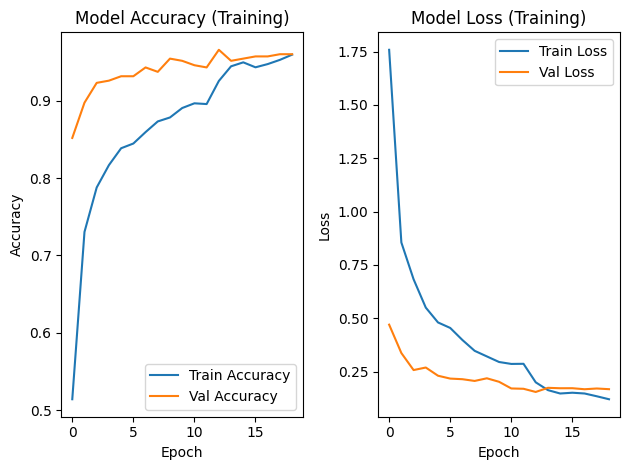

In [23]:
# Plot training history

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Model Accuracy (Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Model Loss (Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
 
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation on test set.
print("Evaluating on unseen test set...")

test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)
print(f"\nTest accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest loss: {test_loss:.4f}")


Evaluating on unseen test set...
17/23 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - accuracy: 0.9422 - loss: 0.2728

In [ ]:
# Take one batch from test set
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


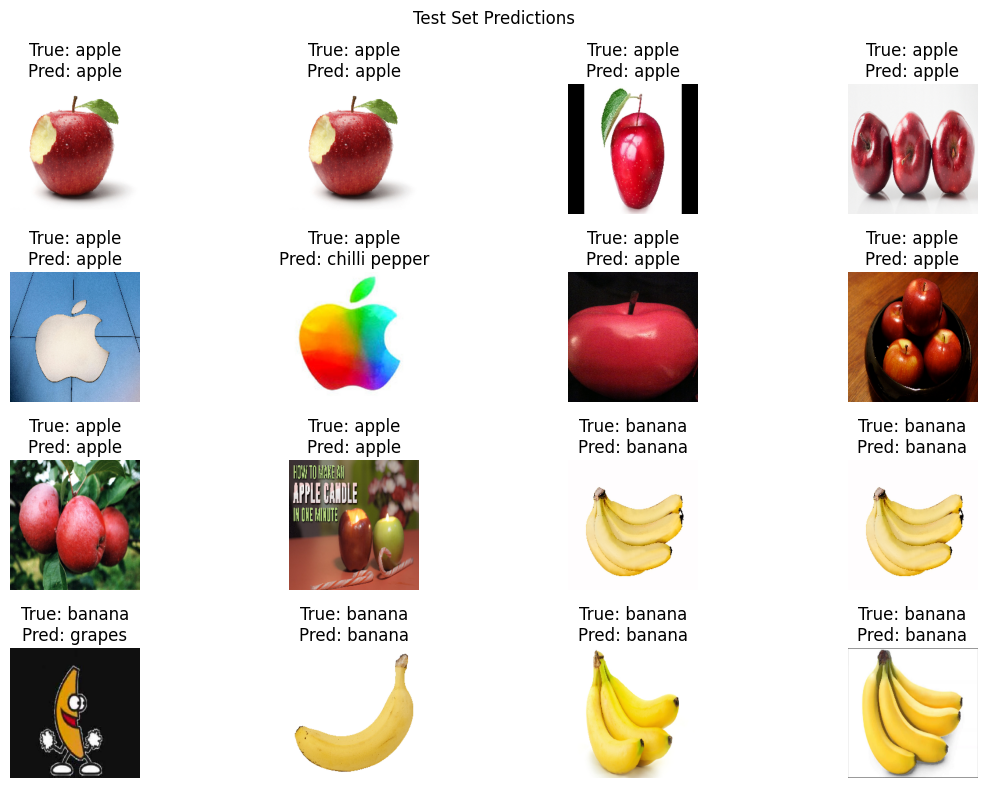

In [ ]:
# Show first 6 predictions
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {CLASS_NAMES[true_classes[i]]}\nPred: {CLASS_NAMES[pred_classes[i]]}")
    plt.axis('off')
plt.suptitle("Test Set Predictions")
plt.tight_layout()
plt.show()